# JLM and JLMB semi-microscopic optical potentials


In [1]:
import matplotlib as mpl
import matplotlib.pyplot as plt
import numpy as np

In [2]:
from jitr.folding import ILDAFolder, jlm
from jitr.utils import density
from jitr.utils.density import TwoParameterFermiDensity

# Optical potential from nuclear matter

The JLM (for J. P. Jeukenne, A. Lejeune, and C. Mahaux) model for the nuclear matter self-energy is included in jitr, as defined in the seminal works [JLM, 1974](https://journals.aps.org/prc/abstract/10.1103/PhysRevC.10.1391), [JLM, 1977a](https://journals.aps.org/prc/abstract/10.1103/PhysRevC.16.80), and [JLM, 1977b](https://journals.aps.org/prc/abstract/10.1103/PhysRevC.15.10).

The goal was to try to model an effective interactions (optical potentials) for nucleons scattering on nuclei by treating the many-body dynamics as if that nucleon where interacting with a system of *homogenous nuclear matter*. This work takes multiple steps:

1. Brueckner-Hartree Fock calculations of the self-energy in symmetric nuclear matter and nuclear matter with neutron excess, using Reid's hard core interaction, at various matter densities (Fermi momenta) and a range of positive energies from 10 to 160 MeV, producing isoscalar and isovector potentials that are functions of matter density $\rho$ and projectile energy $E$: $\Sigma(\rho,E)$.
2. determine a model for the density distribution of a finite nucleus $\rho(r)$
3. Evaluate the optical potential for the finite nucleus in the *local density approximation*: $\Sigma(r,E) = \Sigma(\rho(r),E)$

Later, E. Bauge, J. P. Delaroche, and M. Girod updated this JLM microscopic optical potential in various ways, including adjusting the energy dependence to fit to scattering data (See [BDG 1998](https://journals.aps.org/prc/abstract/10.1103/PhysRevC.58.1118) and [BDG, 2001](https://journals.aps.org/prc/abstract/10.1103/PhysRevC.63.024607)). This is known as the JLMB semi-microscopic optical potential, and it is included in the reaction code [TALYS](https://github.com/arjankoning1/talys/), which is used for nuclear data evaluation.

In this notebook, we will describe both of these models, and demonstrate their implementation in `jitr`.

### The nuclear matter self energy


The first step is to determine the isoscalar and isovector nuclear matter self-energies:

\begin{equation}
U(\rho,E) = V_0(\rho,E) + i W(\rho,E) \pm \alpha \left( V_0(\rho,E) + i W(\rho,E) \right),
\end{equation}

with $\alpha = (\rho_n - \rho_p) / (\rho_n + \rho_p)$, and the $+(-)$ sign is for neutrons(protons).

The isoscalar real self energy, $V_0(\rho,E)$ was parameterized as a polynomial fit to the BHF results:

\begin{equation}
V_0(\rho,E) = \sum_{ij} a_{ij} \rho^i E^{j-1}.
\end{equation}

The isoscalar imaginary part $W_0(\rho,E)$ was parameterized as 


\begin{equation}
W_0(\rho,E) = \frac{\sum_{ij} d_{ij} \rho^i E^{j-1} }{1 + D / (E -\epsilon_F)^2} ,
\end{equation}

with $D=600$ and the Fermi energy parameterized from the Brueckner-Hartree-Fock result as:


\begin{equation}
\epsilon_F(\rho) = \sum_{i=1}^3 k_{i} \rho^i.
\end{equation}

The isovector real and imaginary parts are respectively defined as 


\begin{align}
\begin{split}
V_1(\rho,E) &= \frac{\tilde{m}(\rho,E)}{m} \mathfrak{Re} N(\rho,E) \\ & \\ 
W_1(\rho,E) &=   \frac{m}{\bar{m}(\rho,E)} \mathfrak{Im} N(\rho,E),
\end{split}
\end{align}


where $N(\rho,E)$ is extracted from the Coulomb-corrected difference of the neutron and proton self-energies in nuclear matter, with a given neutron excess (See [JLM, 1977b](https://journals.aps.org/prc/abstract/10.1103/PhysRevC.15.10)). $N$ is parameterized as:

\begin{align}
\begin{split}
\mathfrak{Re} N(\rho,E) &= \sum_{ij} b_{ij} \rho^i E^{j-1}  \\ & \\
\mathfrak{Im} N(\rho,E) &= \frac{\sum_{ij} f_{ij} \rho^i E^{j-1} }{1 + F / (E -\epsilon_F)},
\end{split}
\end{align}


with $F=1$. The $k$-mass, $\tilde{m}(\rho,E)$ is parameterized as 


\begin{equation}
\frac{\tilde{m}(\rho,E)}{m} = 1 - \sum_{ij} c_{ij} \rho^i E^{j-1}.
\end{equation}

The $E$-mass $\bar{m}(\rho,E)$ can be obtained from

\begin{equation}
\frac{m^\star(\rho,E)}{m} = \frac{\tilde{m}(\rho,E)}{m} \frac{\bar{m}(\rho,E)}{m},
\end{equation}

where the effective mass is defined
\begin{equation}
\frac{m^\star(\rho,E)}{m} = 1 - \frac{d}{dE} V_0(\rho,E) = 1 - \sum_{ij} (j-1) a_{ij} \rho^i E^{j-2}.
\end{equation}

In total, there are 5 coefficient matrices, $a$, $b$, $c$, $d$, $f$.

These are included in `jitr.folding.jlm`.


In [3]:
rho_sat_fm3 = 0.16

In [4]:
jlm.fermi_energy_MeV(rho_sat_fm3)

np.float64(-24.844800000000003)

In [5]:
rho_grid = np.linspace(0.01, 0.2, 50)
E_vals = np.linspace(0.1, 170, 80)

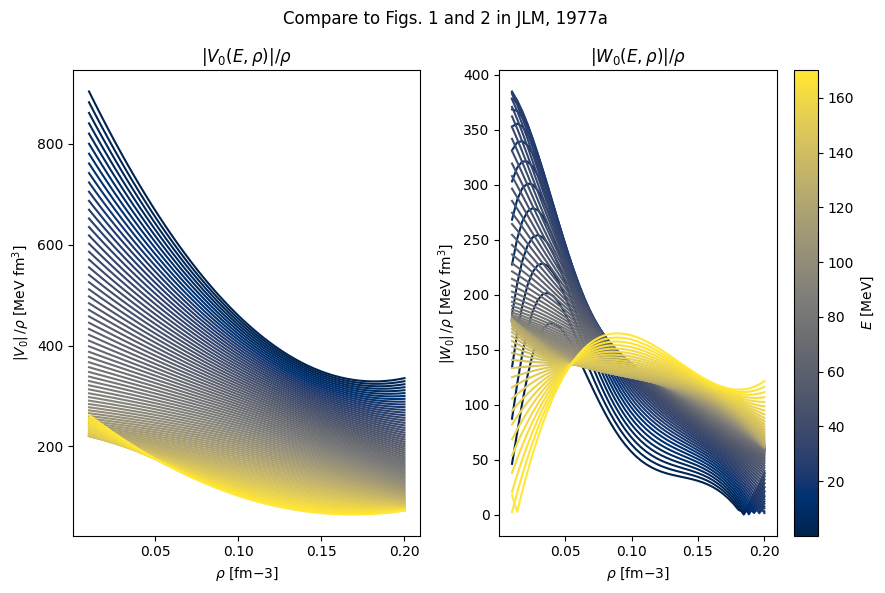

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(9, 6), sharey=False)
cmap = plt.cm.cividis
norm = mpl.colors.Normalize(vmin=E_vals.min(), vmax=E_vals.max())
E_F = jlm.fermi_energy_MeV(rho_grid)
for E in E_vals:

    axes[0].plot(
        rho_grid,
        np.abs(jlm.V0(rho_grid, E)) / rho_grid,
        color=cmap(norm(E)),
        label=f"{E:1.0f} MeV",
    )
    axes[1].plot(
        rho_grid,
        np.abs(jlm.W0(rho_grid, E, E_F=E_F)) / rho_grid,
        label=f"{E:1.0f} MeV",
        color=cmap(norm(E)),
    )

axes[0].set_title(r"$|V_0(E,\rho)| / \rho$")
axes[0].set_ylabel(r"$|V_0 | \, / \rho $ [MeV fm$^3$]")
axes[0].set_xlabel(r"$\rho$ [fm${-3}$]")

axes[1].set_title(r"$|W_0(E,\rho)| / \rho$")
axes[1].set_xlabel(r"$\rho$ [fm${-3}$]")
axes[1].set_ylabel(r"$|W_0 | \, / \rho $ [MeV fm$^3$]")
# axes[1].legend()


sm = mpl.cm.ScalarMappable(norm=norm, cmap=cmap)
sm.set_array([])

cbar = fig.colorbar(sm, ax=axes[1])
cbar.set_label("$E$ [MeV]")

fig.suptitle("Compare to Figs. 1 and 2 in JLM, 1977a")

plt.tight_layout()
plt.show()

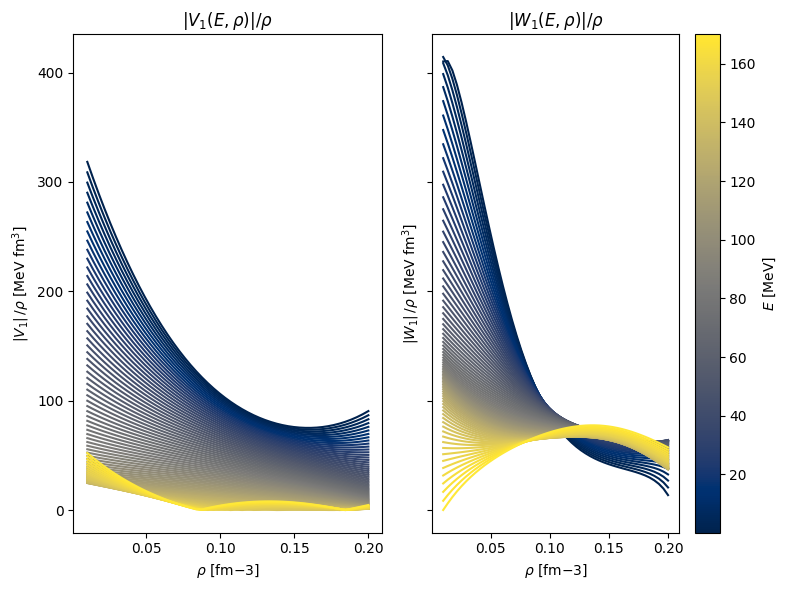

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(8, 6), sharey=True)
E_F = jlm.fermi_energy_MeV(rho_grid)
for E in E_vals:
    axes[0].plot(
        rho_grid,
        np.abs(jlm.V1(rho_grid, E, E_F=E_F)) / rho_grid,
        color=cmap(norm(E)),
        label=f"{E:1.0f} MeV",
    )
    axes[1].plot(
        rho_grid,
        np.abs(jlm.W1(rho_grid, E, E_F=E_F)) / rho_grid,
        label=f"{E:1.0f} MeV",
        color=cmap(norm(E)),
    )

axes[0].set_title(r"$|V_1(E,\rho)| / \rho$")
axes[0].set_ylabel(r"$|V_1 | \, / \rho $ [MeV fm$^3$]")
axes[0].set_xlabel(r"$\rho$ [fm${-3}$]")

axes[1].set_title(r"$|W_1(E,\rho)| / \rho$")
axes[1].set_xlabel(r"$\rho$ [fm${-3}$]")
axes[1].set_ylabel(r"$|W_1 | \, / \rho $ [MeV fm$^3$]")
# axes[1].legend()
sm = mpl.cm.ScalarMappable(norm=norm, cmap=cmap)
sm.set_array([])

cbar = fig.colorbar(sm, ax=axes[1])
cbar.set_label("$E$ [MeV]")


plt.tight_layout()
plt.show()

## Folding to finite nuclear density
We will use the local density approximation and improved local density approximations. First, let's grab some density distributions:

In [8]:
def pb208_densities_2pf():
    rho_n = TwoParameterFermiDensity(R=6.6, a=0.55, N=126)
    rho_p = TwoParameterFermiDensity(R=6.3, a=0.547, N=82)
    return rho_p, rho_n

In [9]:
target = (208, 82)
neutron = (1, 0)
proton = (1, 1)

R = np.linspace(0.0, 12.0, 201)

rho_p_2pf, rho_n_2pf = pb208_densities_2pf()
rho_p_d1m, rho_n_d1m = density.densities(208, 82, R, model="d1m")
rho_p_bskg3, rho_n_bskg3 = density.densities(208, 82, R, model="bskg3")

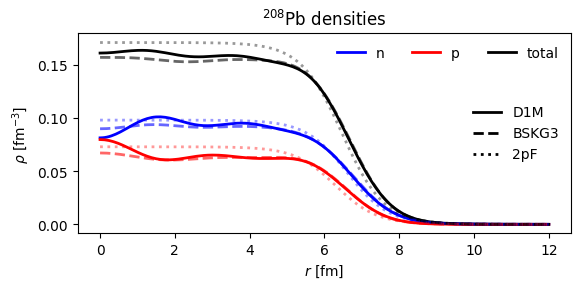

In [10]:
fig, ax = plt.subplots(figsize=(6, 3))
legend_handles_density_type = [
    ax.plot(R, rho_n_d1m, color="b", label="n", linewidth=2)[0],
    ax.plot(R, rho_p_d1m, color="r", label="p", linewidth=2)[0],
    ax.plot(R, rho_n_d1m + rho_p_d1m, color="k", label="total", linewidth=2)[0],
]

plt.plot(R, rho_n_bskg3, "--", color="b", linewidth=2, alpha=0.6)
plt.plot(R, rho_p_bskg3, "--", color="r", linewidth=2, alpha=0.6)
plt.plot(R, rho_n_bskg3 + rho_p_bskg3, "--", color="k", linewidth=2, alpha=0.6)


plt.plot(R, rho_n_2pf(R), ":", color="b", linewidth=2, alpha=0.4)
plt.plot(R, rho_p_2pf(R), ":", color="r", linewidth=2, alpha=0.4)
plt.plot(R, rho_n_2pf(R) + rho_p_2pf(R), ":", color="k", linewidth=2, alpha=0.4)

leg1 = ax.legend(
    handles=legend_handles_density_type, framealpha=0, ncol=3, loc="upper right"
)
leg2 = plt.legend(
    handles=[
        plt.plot([], [], color="k", linewidth=2, label="D1M")[0],
        plt.plot([], [], "--", color="k", linewidth=2, label="BSKG3")[0],
        plt.plot([], [], ":", color="k", linewidth=2, label="2pF")[0],
    ],
    framealpha=0,
    loc="center right",
)

ax.add_artist(leg1)

plt.xlabel(r"$r$ [fm]")
plt.ylabel(r"$\rho$ [fm$^{-3}$]")
plt.title(r"$^{208}$Pb densities")
plt.tight_layout()
plt.show()

### Local density approximation (LDA)

The LDA is a simple prescription. Given a nuclear matter self-energy $U(\rho,E)$ and a density profile $\rho(r)$:

\begin{equation}
U(r,E) = U(\rho(r),E)
\end{equation}

From [JLM, 1977b](https://journals.aps.org/prc/abstract/10.1103/PhysRevC.16.80):

> [the] local density approximation
(LDA) ascribes to the OMP at the density $\rho(r)$ the
same value as in a uniform medium with the same
value of the density, with the same neutron excess,
and at the same energy.

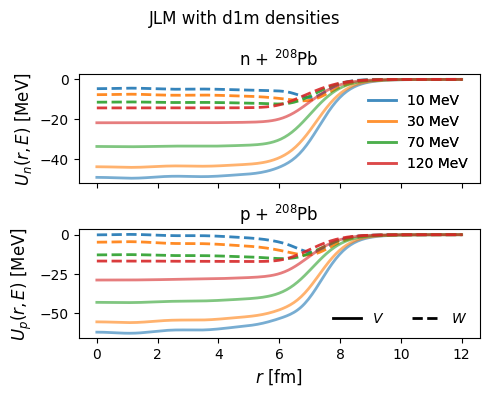

In [11]:
fig, axes = plt.subplots(2, 1, sharex=True, figsize=(5, 4))
handles_energy = []
folder_local = ILDAFolder(r_max=20.0, n_quad=200)
V_C_local = folder_local.V_coulomb(
    folder_local.interp_to_quad(R, rho_p_d1m),
    mode="density",
    include_exchange=True,
    r_out=R,
)
for E in [10, 30, 70, 120]:
    V, W = jlm.potential_JLM(R, rho_n_d1m + rho_p_d1m, (1, 0), target, E)
    (p,) = axes[0].plot(R, V, linewidth=2, label=f"{E:1.0f} MeV", alpha=0.6)
    axes[0].plot(R, W, "--", linewidth=2, color=p.get_color(), alpha=0.9)
    handles_energy.append(p)
    V, W = jlm.potential_JLM(
        R,
        rho_n_d1m + rho_p_d1m,
        (1, 1),
        target,
        E,
        V_C=V_C_local,
        parameterization="talys",
    )
    axes[1].plot(R, V, linewidth=2, color=p.get_color(), alpha=0.6)
    axes[1].plot(R, W, "--", linewidth=2, color=p.get_color(), alpha=0.9)

leg1 = axes[0].legend(handles=handles_energy, framealpha=0, ncol=1, loc="lower right")
leg2 = axes[1].legend(
    handles=[
        plt.plot([], [], color="k", linewidth=2, label=r"$V$")[0],
        plt.plot([], [], "--", color="k", linewidth=2, label="$W$")[0],
    ],
    framealpha=0,
    ncol=2,
    loc="lower right",
)
axes[0].add_artist(leg1)


axes[1].set_xlabel(r"$r$ [fm]", fontsize=12)
axes[0].set_ylabel(r"$U_n(r,E)$ [MeV]", fontsize=12)
axes[1].set_ylabel(r"$U_p(r,E)$ [MeV]", fontsize=12)
axes[0].set_title(r"n + $^{208}$Pb", fontsize=12)
axes[1].set_title(r"p + $^{208}$Pb", fontsize=12)
fig.suptitle("JLM with d1m densities")
plt.tight_layout()
plt.show()

### Volume integrals in the LDA

In [12]:
energies = np.linspace(10, 200, 200)
Ju_A = np.zeros_like(energies, dtype=complex)
projectile = neutron
A = target[0]
for i, E in enumerate(energies):
    V, W = jlm.potential_JLM(R, rho_n_d1m + rho_p_d1m, projectile, target, E)
    Jv_A = 4 * np.pi / A * np.trapezoid(V * R**2, R)
    Jw_A = 4 * np.pi / A * np.trapezoid(W * R**2, R)
    Ju_A[i] = Jv_A + 1j * Jw_A

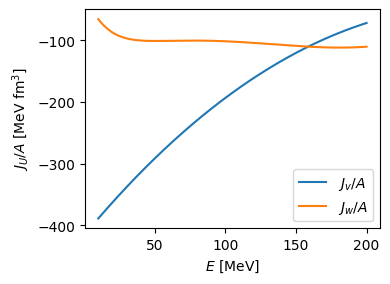

In [13]:
fig = plt.figure(figsize=(4, 3))
plt.plot(energies, Ju_A.real, label=r"$J_v/A$")
plt.plot(energies, Ju_A.imag, label=r"$J_w/A$")
plt.legend()
plt.xlabel("$E$ [MeV]")
plt.ylabel("$J_U / A$ [MeV fm$^3$]")
plt.tight_layout()
plt.show()

## JLMB and the improved LDA (ILDA)

The JLM formalism was later updated to separately use the neutron and proton densities to determine the isovector dependence of the optical potential, as well renormalize the depths to fit elastic scattering experiments:

- [Bauge, Delaroche, & Girod, 1998](https://journals.aps.org/prc/abstract/10.1103/PhysRevC.58.1118)
- [Bauge, Delaroche, & Girod, 2001](https://journals.aps.org/prc/abstract/10.1103/PhysRevC.63.024607)

Additionally, rather than using the LDA as above, the finite nucleus self-energy as calculated above is convolved with a Gaussian with isovector-dependent range $t \sim 1$ fm.

In [14]:
folder = ILDAFolder(r_max=20.0, n_quad=200)  # once

# interpolate densities onto quadrature g
rho_n_q = folder.interp_to_quad(R, rho_n_d1m)
rho_p_q = folder.interp_to_quad(R, rho_p_d1m)

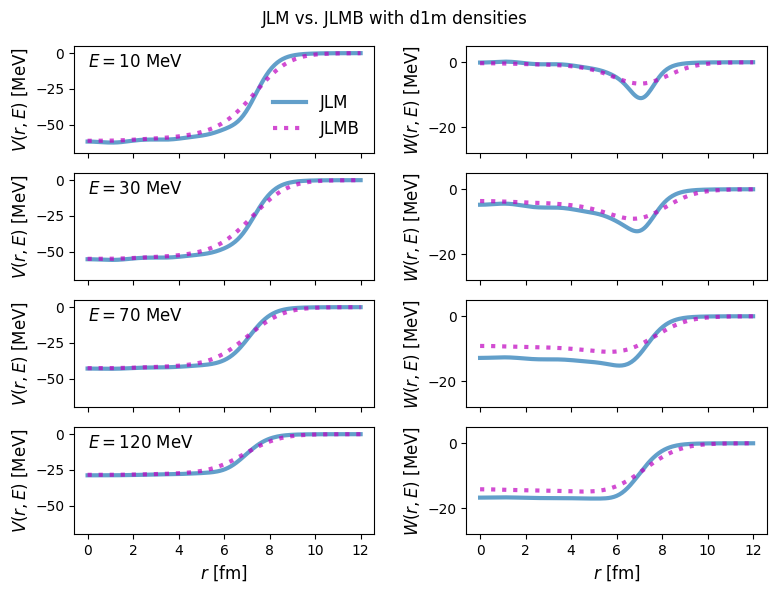

In [15]:
energies = [10, 30, 70, 120]
projectile = proton
V_C_q = folder.V_coulomb(rho_p_q, mode="density", include_exchange=True)
V_C_R = folder.V_coulomb(rho_p_q, mode="density", include_exchange=True, r_out=R)

fig, axes = plt.subplots(len(energies), 2, sharex=True, figsize=(8, 6))
axes = np.array(axes)
for i, E in enumerate(energies):
    V_n_jlm, W_n_jlm = jlm.potential_JLM(
        R,
        rho_n_d1m + rho_p_d1m,
        projectile,
        target,
        E,
        V_C=V_C_R,
        parameterization="talys",
    )
    V_n_jlmb, W_n_jlmb = jlm.potential_JLMB(
        folder,
        rho_n_q,
        rho_p_q,
        projectile,
        target,
        E,
        V_C=V_C_q,
        parameterization="talys",
        r_out=R,
        lambda_V=jlm.lambda_v0(E),
        lambda_V1=jlm.lambda_v1(E),
        lambda_W=jlm.lambda_w0(E),
        lambda_W1=jlm.lambda_w1(E),
    )

    axes[i, 0].plot(R, V_n_jlm, linewidth=3, alpha=0.7, color="tab:blue", label="JLM")
    axes[i, 0].plot(R, V_n_jlmb, ":", linewidth=3, color="m", alpha=0.7, label="JLMB")
    axes[i, 0].set_ylabel(r"$V(r,E)$ [MeV]", fontsize=12)
    axes[i, 0].text(0, -10, f"$E = ${E:1.0f} MeV", fontsize=12)
    axes[i, 0].set_ylim([-70, 5])

    axes[i, 1].plot(R, W_n_jlm, linewidth=3, alpha=0.7, color="tab:blue", label="JLM")
    axes[i, 1].plot(R, W_n_jlmb, ":", linewidth=3, color="m", alpha=0.7, label="JLMB")
    axes[i, 1].set_ylabel(r"$W(r,E)$ [MeV]", fontsize=12)
    axes[i, 1].set_ylim([-28, 5])


axes[0, 0].legend(loc="lower right", framealpha=0, fontsize=12)
axes[-1, 0].set_xlabel(r"$r$ [fm]", fontsize=12)
axes[-1, 1].set_xlabel(r"$r$ [fm]", fontsize=12)
fig.suptitle("JLM vs. JLMB with d1m densities")
plt.tight_layout()
plt.show()

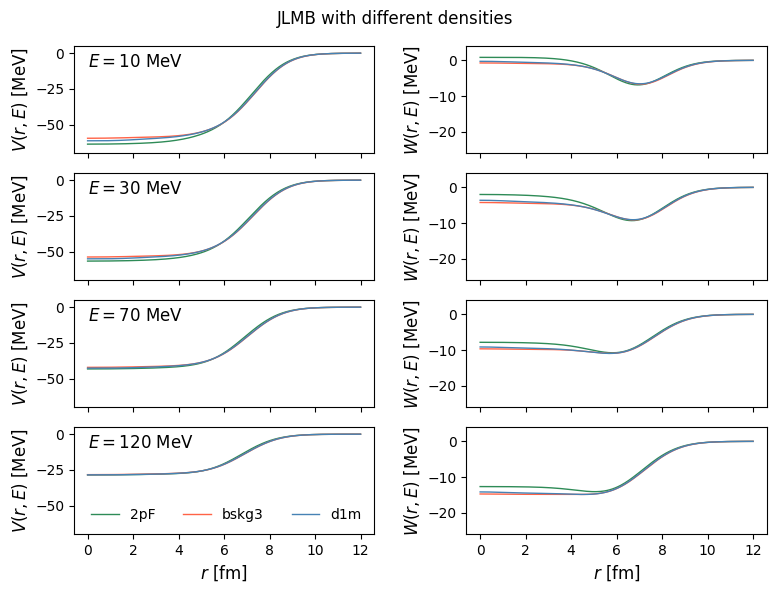

In [16]:
energies = [10, 30, 70, 120]
projectile = proton

# interpolate densities onto quadrature grid
densities_at_nodes = {
    label: (folder.interp_to_quad(R, rho_n), folder.interp_to_quad(R, rho_p))
    for label, rho_n, rho_p in [
        ("2pF", rho_n_2pf(R), rho_p_2pf(R)),
        ("bskg3", rho_n_bskg3, rho_p_bskg3),
        ("d1m", rho_n_d1m, rho_p_d1m),
    ]
}

colors = {
    "2pF": "#2E8B57",
    "d1m": "#4682B4",
    "bskg3": "#FF6347",
}

fig, axes = plt.subplots(len(energies), 2, sharex=True, figsize=(8, 6))
axes = np.array(axes)
for i, E in enumerate(energies):
    for model_name, (rho_n_q, rho_p_q) in densities_at_nodes.items():
        V_C_q = folder.V_coulomb(rho_p_q, mode="density", include_exchange=True)
        V, W = jlm.potential_JLMB(
            folder,
            rho_n_q,
            rho_p_q,
            projectile,
            target,
            E,
            V_C=V_C_q,
            parameterization="talys",
            r_out=R,
            lambda_V=jlm.lambda_v0(E),
            lambda_V1=jlm.lambda_v1(E),
            lambda_W=jlm.lambda_w0(E),
            lambda_W1=jlm.lambda_w1(E),
        )

        axes[i, 0].plot(
            R, V, linewidth=1, alpha=1, color=colors[model_name], label=model_name
        )
        axes[i, 1].plot(R, W, linewidth=1, alpha=1, color=colors[model_name])

    axes[i, 0].set_ylabel(r"$V(r,E)$ [MeV]", fontsize=12)
    axes[i, 0].text(0, -10, f"$E = ${E:1.0f} MeV", fontsize=12)
    axes[i, 0].set_ylim([-70, 5])
    axes[i, 1].set_ylabel(r"$W(r,E)$ [MeV]", fontsize=12)
    axes[i, 1].set_ylim([-26, 4])


axes[-1, 0].legend(loc="lower right", framealpha=0, fontsize=10, ncol=3)
axes[-1, 0].set_xlabel(r"$r$ [fm]", fontsize=12)
axes[-1, 1].set_xlabel(r"$r$ [fm]", fontsize=12)
fig.suptitle("JLMB with different densities")
plt.tight_layout()
plt.show()

In [17]:
energies = np.linspace(0.01, 300, 200)
Ju_A_JLM = np.zeros_like(energies, dtype=complex)
Ju_A_JLMB = np.zeros_like(energies, dtype=complex)
Ju_A_JLMB_no_renorm = np.zeros_like(energies, dtype=complex)

projectile = neutron
A = target[0]
for i, E in enumerate(energies):
    V, W = jlm.potential_JLM(R, rho_n_d1m + rho_p_d1m, projectile, target, E)
    Ju_A_JLM[i] = np.trapezoid(V * R**2, R) + 1j * np.trapezoid(W * R**2, R)

    V, W = jlm.potential_JLMB(
        folder,
        rho_n_q,
        rho_p_q,
        projectile,
        target,
        E,
        lambda_V=jlm.lambda_v0(E),
        lambda_V1=jlm.lambda_v1(E),
        lambda_W=jlm.lambda_w0(E),
        lambda_W1=jlm.lambda_w1(E),
    )
    Ju_A_JLMB[i] = folder.integrate(V * folder.r_q**2) + 1j * folder.integrate(
        W * folder.r_q**2
    )

    V, W = jlm.potential_JLMB(
        folder,
        rho_n_q,
        rho_p_q,
        projectile,
        target,
        E,
    )
    Ju_A_JLMB_no_renorm[i] = folder.integrate(
        V * folder.r_q**2
    ) + 1j * folder.integrate(W * folder.r_q**2)

Ju_A_JLM *= 4 * np.pi / A
Ju_A_JLMB *= 4 * np.pi / A
Ju_A_JLMB_no_renorm *= 4 * np.pi / A

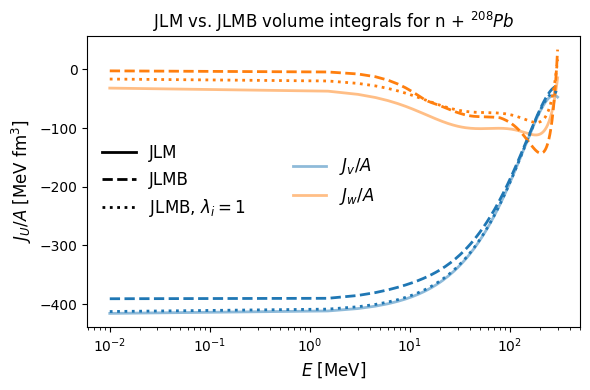

In [18]:
fig, ax = plt.subplots(1, 1, figsize=(6, 4))

legend_handles_term = [
    plt.plot(
        energies,
        Ju_A_JLM.real,
        linewidth=2,
        color="tab:blue",
        alpha=0.5,
        label=r"$J_v/A$",
    )[0],
    plt.plot(
        energies,
        Ju_A_JLM.imag,
        linewidth=2,
        color="tab:orange",
        alpha=0.5,
        label=r"$J_w/A$",
    )[0],
]
plt.plot(energies, Ju_A_JLMB.real, "--", linewidth=2, color="tab:blue")
plt.plot(energies, Ju_A_JLMB.imag, "--", linewidth=2, color="tab:orange")
plt.plot(energies, Ju_A_JLMB_no_renorm.real, ":", linewidth=2, color="tab:blue")
plt.plot(energies, Ju_A_JLMB_no_renorm.imag, ":", linewidth=2, color="tab:orange")

leg1 = ax.legend(
    handles=legend_handles_term,
    framealpha=0,
    ncol=1,
    loc="center",
    fontsize=12,
)
leg2 = plt.legend(
    handles=[
        plt.plot([], [], color="k", linewidth=2, label="JLM")[0],
        plt.plot([], [], "--", color="k", linewidth=2, label="JLMB")[0],
        plt.plot([], [], ":", color="k", linewidth=2, label=r"JLMB, $\lambda_i = 1$")[
            0
        ],
    ],
    framealpha=0,
    loc="center left",
    fontsize=12,
)
ax.add_artist(leg1)


plt.xscale("log")
plt.xlabel("$E$ [MeV]", fontsize=12)
plt.ylabel("$J_U / A$ [MeV fm$^3$]", fontsize=12)
ax.set_title(r"JLM vs. JLMB volume integrals for n + $^{208}Pb$", fontsize=12)
plt.tight_layout()
plt.show()

Note that, when we set $\lambda_i=1$, neglecting the renormalization, JLM and JLMB nearly agree. The bulk of difference in the energy dependence of JLM and JLMB comes from the renormalization as opposed to the isovector effect or the ILDA. The notable exception to this is the imaginary part below $\sim 200$ MeV where the Lane consistency uniformly decreases absorptive strength for neutrons on the neutron rich $^{208}$Pb.

## Comparison of ways to compue the Coulomb potential from the proton density

There are a few options built into `jitr.folding.ILDAFolder`. One can:

1. use the analytic, oft-used, uniform sphere convention, with the Coulomb radius determined friom a given proton density
2. use the full direct Coulomb potential
3. use the full Coulomb potential using the Slater local approximation to the exchange term

In [19]:
rho_p_q = folder.interp_to_quad(R, rho_p_d1m)
V_Coulomb_uniform_sphere = folder.V_coulomb(rho_p_q, mode="uniform_sphere")
V_Coulomb_full = folder.V_coulomb(rho_p_q, mode="density")
V_Coulomb_full_exchange = folder.V_coulomb(
    rho_p_q, mode="density", include_exchange=True
)

Text(0, 0.5, '$V_C(r)$')

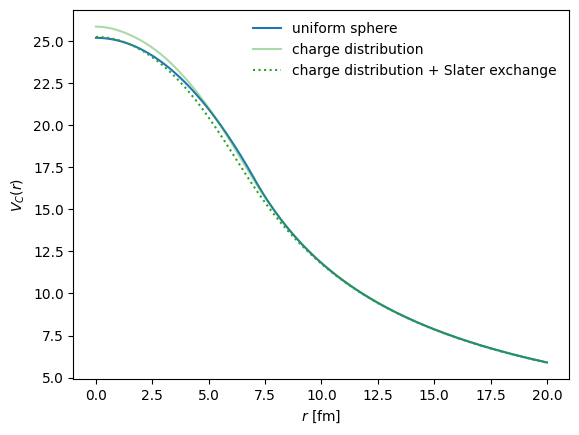

In [20]:
plt.plot(folder.r_q, V_Coulomb_uniform_sphere, label="uniform sphere")
plt.plot(
    folder.r_q,
    V_Coulomb_full,
    alpha=0.4,
    color="tab:green",
    label="charge distribution",
)
plt.plot(
    folder.r_q,
    V_Coulomb_full_exchange,
    ":",
    color="tab:green",
    label="charge distribution + Slater exchange",
)
plt.legend(framealpha=0)
plt.xlabel("$r$ [fm]")
plt.ylabel("$V_C(r)$")

## Comparison of JLM and JLMB cross section predictions

Finally, we set up as `Solver` and compare cross sections predictions.

In [21]:
from jitr import reactions, rmatrix, utils, xs

In [22]:
# calculate kinematics for a given lab energy
energy_lab = 60
projectile = proton
reaction = reactions.Reaction(target=target, projectile=proton, process="el")
kinematics = reaction.kinematics(energy_lab)

# set the channel radius, number of nodes, and number of partial waves
interaction_range_fm = 1.2 * (target[0] ** (1 / 3)) + 2
channel_radius_dimensionless = utils.suggested_dimensionless_channel_radius(
    interaction_range_fm, kinematics.k
)
channel_radius = channel_radius_dimensionless / kinematics.k
N = utils.suggested_basis_size(channel_radius_dimensionless)
lmax = 60

# build a solver for the system and reaction of interest
print(f"Compiling solver for {reaction} at {energy_lab} MeV")
print(f" - channel radius {channel_radius:1.2f} fm")
print(f" - {N} nodes")
print(f" - {lmax} partial waves")

solver = xs.elastic.DifferentialWorkspace.build_from_system(
    reaction=reaction,
    kinematics=kinematics,
    channel_radius_fm=channel_radius,
    solver=rmatrix.Solver(N),
    lmax=lmax,
    angles=np.linspace(0.1, np.pi, 180),
)
rgrid = solver.radial_grid()
# jit warmup
_ = solver.xs(central_potential=np.zeros_like(solver.radial_grid()))
print("Done!")

Compiling solver for 208-Pb(p,el) at 60 MeV
 - channel radius 12.77 fm
 - 35 nodes
 - 60 partial waves
Done!


Now let's compare the effects of the LDA vs. the ILDA on a differential cross section. We will use JLM and JLMB without the the energy renormalization ($\lambda_i=1$).

In [23]:
def get_potentials(solver, reaction, r_grid, rho_n, rho_p):
    rho_n_q = folder.interp_to_quad(r_grid, rho_n)
    rho_p_q = folder.interp_to_quad(r_grid, rho_p)
    V_C_q = folder.V_coulomb(
        rho_p_q,
        mode="density",
        include_exchange=True,
    )
    V_C = folder.V_coulomb(
        rho_p_q,
        mode="density",
        include_exchange=True,
        r_out=solver.radial_grid(),
    )
    jlmb_kwargs = {}
    jlm_kwargs = {}
    if reaction.projectile == proton:
        jlmb_kwargs = {
            "V_C": V_C_q,
            "parameterization": "talys",
        }
        jlm_kwargs = {
            "V_C": V_C,
            "parameterization": "talys",
        }
    V_jlmb, W_jlmb = jlm.potential_JLMB(
        folder,
        rho_n_q,
        rho_p_q,
        reaction.projectile,
        reaction.target,
        kinematics.Ecm,
        **jlmb_kwargs,
        r_out=solver.radial_grid(),
    )
    V_jlm, W_jlm = jlm.potential_JLM(
        solver.radial_grid(),
        np.interp(solver.radial_grid(), r_grid, rho_n + rho_p),
        reaction.projectile,
        reaction.target,
        kinematics.Ecm,
        **jlm_kwargs,
    )
    return V_C, (V_jlm, W_jlm), (V_jlmb, W_jlmb)

In [24]:
V_C, (V_jlm, W_jlm), (V_jlmb, W_jlmb) = get_potentials(
    solver, reaction, R, rho_n_d1m, rho_p_d1m
)

In [25]:
%%time
rho_n_q = folder.interp_to_quad(R, rho_n_d1m)
rho_p_q = folder.interp_to_quad(R, rho_p_d1m)
xs_jlm = solver.xs(
    central_potential=V_jlm + 1j * W_jlm,
    coulomb_potential=V_C,
)
xs_jlmb = solver.xs(
    central_potential=V_jlmb + 1j * W_jlmb,
    coulomb_potential=V_C,
)

CPU times: user 12.4 ms, sys: 968 μs, total: 13.4 ms
Wall time: 12.4 ms


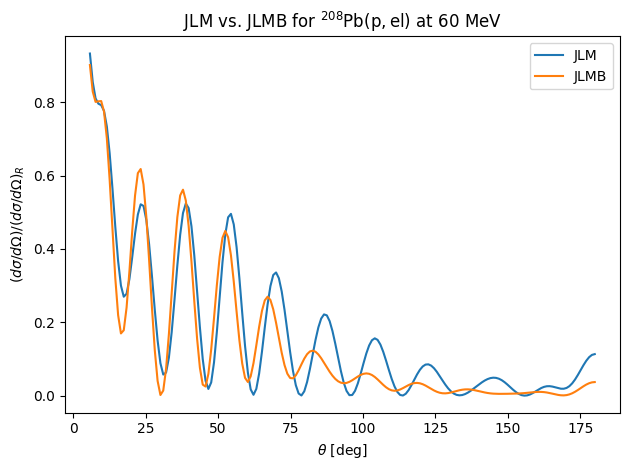

In [26]:
plt.plot(np.rad2deg(solver.angles), xs_jlm.dsdo / solver.rutherford, label="JLM")
plt.plot(np.rad2deg(solver.angles), xs_jlmb.dsdo / solver.rutherford, label="JLMB")
plt.xlabel(r"$\theta$ [deg]")
plt.ylabel(r"$(d\sigma/d\Omega) / (d\sigma / d\Omega)_{R} $")
plt.title(f"JLM vs. JLMB for ${reaction.reaction_latex}$ at {kinematics.Elab} MeV")
plt.legend()
plt.tight_layout()

The ILDA produces more diffuse surfaces, so the diffraction oscillations become less pronounced.

## Effect of densities on cross sections

In [27]:
# calculate kinematics for a given lab energy
energy_lab = 20
projectile = neutron
reaction = reactions.Reaction(target=target, projectile=projectile, process="el")
kinematics = reaction.kinematics(energy_lab)

# set the channel radius, number of nodes, and number of partial waves
interaction_range_fm = 1.2 * (target[0] ** (1 / 3)) + 2
channel_radius_dimensionless = utils.suggested_dimensionless_channel_radius(
    interaction_range_fm, kinematics.k
)
channel_radius = channel_radius_dimensionless / kinematics.k
N = utils.suggested_basis_size(channel_radius_dimensionless)
lmax = 60

# build a solver for the system and reaction of interest
print(f"Compiling solver for {reaction} at {energy_lab} MeV")
print(f" - channel radius {channel_radius:1.2f} fm")
print(f" - {N} nodes")
print(f" - {lmax} partial waves")

solver = xs.elastic.DifferentialWorkspace.build_from_system(
    reaction=reaction,
    kinematics=kinematics,
    channel_radius_fm=channel_radius,
    solver=rmatrix.Solver(N),
    lmax=lmax,
    angles=np.linspace(0.1, np.pi, 180),
)
rgrid = solver.radial_grid()
# jit warmup
_ = solver.xs(central_potential=np.zeros_like(solver.radial_grid()))
print("Done!")

Compiling solver for 208-Pb(n,el) at 20 MeV
 - channel radius 15.50 fm
 - 25 nodes
 - 60 partial waves
Done!


In [28]:
%%time
densities = {
    label: (rho_n, rho_p)
    for label, rho_n, rho_p in [
        ("2pF", rho_n_2pf(R), rho_p_2pf(R)),
        ("bskg3", rho_n_bskg3, rho_p_bskg3),
        ("d1m", rho_n_d1m, rho_p_d1m),
    ]
}
results_jlmb = {}
results_jlm = {}

for label, (rho_n, rho_p) in densities.items():
    V_C, (V_jlm, W_jlm), (V_jlmb, W_jlmb) = get_potentials(
        solver, reaction, R, rho_n, rho_p
    )
    results_jlm[label] = solver.xs(
        central_potential=V_jlm + 1j * W_jlm,
    )
    results_jlmb[label] = solver.xs(
        central_potential=V_jlmb + 1j * W_jlmb,
    )

CPU times: user 24.7 ms, sys: 974 μs, total: 25.7 ms
Wall time: 23.9 ms


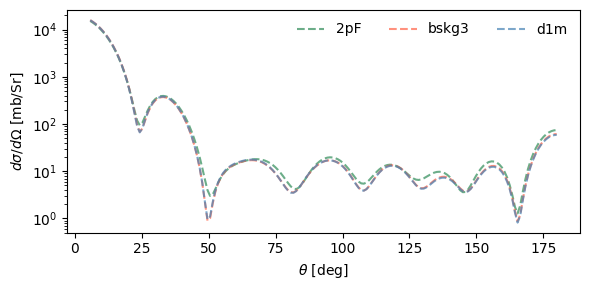

In [29]:
fig, ax = plt.subplots(1, 1, figsize=(6, 3))
for label in densities.keys():
    ax.plot(
        np.rad2deg(solver.angles),
        results_jlmb[label].dsdo,
        "--",
        alpha=0.7,
        color=colors[label],
        label=label,
    )
    # ax.plot(np.rad2deg(solver.angles), xs_jlmb.dsdo / solver.rutherford, color=colors[label], label=label)

ax.set_xlabel(r"$\theta$ [deg]")
ax.set_ylabel(r"$d\sigma/d\Omega$ [mb/Sr]")
ax.set_yscale("log")
plt.legend(ncol=3, framealpha=0)
plt.tight_layout()

In [30]:
goofy_densities = {
    "big skin": (
        TwoParameterFermiDensity(R=6.8, a=0.55, N=126)(R),
        TwoParameterFermiDensity(R=6.0, a=0.547, N=82)(R),
    ),
    "med skin": (
        TwoParameterFermiDensity(R=6.8, a=0.55, N=126)(R),
        TwoParameterFermiDensity(R=6.3, a=0.547, N=82)(R),
    ),
    "small skin": (
        TwoParameterFermiDensity(R=6.8, a=0.55, N=126)(R),
        TwoParameterFermiDensity(R=6.6, a=0.547, N=82)(R),
    ),
    "big skin diffuse": (
        TwoParameterFermiDensity(R=6.8, a=0.6, N=126)(R),
        TwoParameterFermiDensity(R=6.0, a=0.6, N=82)(R),
    ),
    "med skin diffuse": (
        TwoParameterFermiDensity(R=6.8, a=0.6, N=126)(R),
        TwoParameterFermiDensity(R=6.3, a=0.6, N=82)(R),
    ),
    "small skin diffuse": (
        TwoParameterFermiDensity(R=6.8, a=0.6, N=126)(R),
        TwoParameterFermiDensity(R=6.6, a=0.6, N=82)(R),
    ),
}

In [31]:
%%time
results_jlmb = {}
results_jlm = {}

for label, (rho_n, rho_p) in goofy_densities.items():
    V_C, (V_jlm, W_jlm), (V_jlmb, W_jlmb) = get_potentials(
        solver, reaction, R, rho_n, rho_p
    )
    results_jlm[label] = solver.xs(
        central_potential=V_jlm + 1j * W_jlm,
    )
    results_jlmb[label] = solver.xs(
        central_potential=V_jlmb + 1j * W_jlmb,
    )

CPU times: user 48.7 ms, sys: 0 ns, total: 48.7 ms
Wall time: 48.9 ms


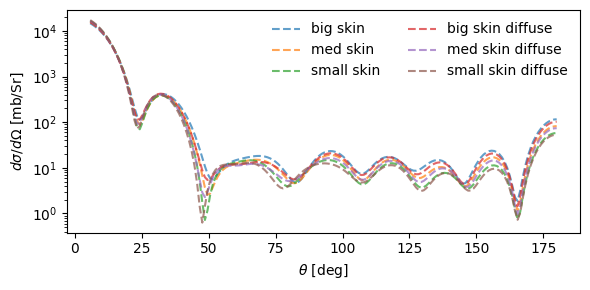

In [32]:
fig, ax = plt.subplots(1, 1, figsize=(6, 3))
for label in goofy_densities.keys():
    ax.plot(
        np.rad2deg(solver.angles),
        results_jlmb[label].dsdo,
        "--",
        alpha=0.7,
        label=label,
    )
    # ax.plot(np.rad2deg(solver.angles), xs_jlmb.dsdo / solver.rutherford, color=colors[label], label=label)

ax.set_xlabel(r"$\theta$ [deg]")
ax.set_ylabel(r"$d\sigma/d\Omega$ [mb/Sr]")
ax.set_yscale("log")
plt.legend(ncol=2, framealpha=0)
plt.tight_layout()